# 🏆 Matched Cohort Benchmark: GELSTM (Frozen GAAE) vs. BrainTokenGT (Stabilized EvolveGCN-H)
## Head-to-Head Longitudinal Evaluation on DELCODE Matched Window ($2 \le T \le 3$ Visits, 4 Seeds $\times$ 5 Folds)

---

### 📋 Executive Summary & Context

This notebook compares **GELSTM (Frozen GAAE)** and **BrainTokenGT (Stabilized EvolveGCN-H)**
on the same matched cohort window from the **DELCODE** functional connectivity dataset.

**Revision, 23 Aug 2026 (`SUBMISSION_RUNWAY.md` Phase B1):** the previous version of this
notebook hardcoded one run path per seed for BrainTokenGT. Seed 42 alone had 6 completed runs
at the reference commit on disk; the hardcoded path picked whichever one happened to run
last (0.6104), understating the arm's own run-to-run spread and overstating GELSTM's margin
in the process. This version ingests **every** completed run for both arms, filtered to one
consistent commit (`STABILITY_AUDIT.md` Finding 1 & 2) — 4 GELSTM runs (1/seed, this arm has
no repeats) and **18 BrainTokenGT runs** (6/4/4/4 across seeds 42\u201345).

### 📊 Results (recomputed live below \u2014 see \u00a72)

| Metric | GELSTM (Frozen GAAE, 2\u20133v) | BrainTokenGT (Stabilized, 2\u20133v) | Margin | Inference |
| :---| :---: | :---: | :---: | :---: |
| **Held-Out Test AUC** (n=4 seed pairs; BT = mean of 18 runs) | **0.8782 \u00b1 0.0256** | 0.6163 \u00b1 0.0679 | **+0.2619** | Wilcoxon p=0.125 (n=4, min attainable); 95% seed-cluster boot. CI **[+0.158, +0.375]** \u2014 excludes zero |
| **Held-Out Test F1** | **0.6902 \u00b1 0.0953** | 0.5375 \u00b1 0.0786 | **+0.1527** | Wilcoxon p=0.125 (n=4) |
| **BrainTokenGT within-seed SD** | \u2014 | **0.090** (mean across seeds) | vs. between-seed-mean SD **0.068** | within-seed noise exceeds between-seed spread |

The corrected BrainTokenGT numbers are *lower* than the notebook previously reported (was
0.6672 \u00b1 0.1008 for AUC) \u2014 the old hardcoded run happened to be one of its better draws,
not a representative one. GELSTM's own numbers are unchanged: this arm has no repeat runs at
this commit, so there was nothing to cherry-pick from.

### 🔑 Key Takeaways

1. **GELSTM's margin holds, and is larger once BrainTokenGT is measured correctly**: mean
   Test AUC advantage widens from the previously-reported +0.2110 to **+0.2619** against the
   full 18-run distribution. The Wilcoxon signed-rank test is underpowered at n=4 seed pairs
   (minimum attainable p=0.125, reached here because GELSTM beats BrainTokenGT's seed mean on
   all 4 seeds), but the seed-cluster bootstrap CI on the margin **excludes zero**
   ([+0.158, +0.375]), which the n=4 test alone cannot show.
2. **Fairness criteria, revised**:
   - **C1. Same dataset & splits**: unchanged \u2014 byte-matched subject IDs and identical fold
     partitions (`verify_matched_cohort_parity.py`).
   - **C2. "Stabilized" means doesn't crash, not reproducible.** BrainTokenGT converges without
     NaNs across all 18 pooled runs, but is **not reproducible at a fixed seed**: within-seed
     SD (0.090) exceeds between-seed-mean SD (0.068), so most of what the original notebook
     attributed to "seed" is run-to-run noise (`STABILITY_AUDIT.md` Finding 1). GELSTM's
     pipeline is separately verified byte-reproducible at a fixed seed (D2 gate on the sibling
     `recon-ablation-gelstm-none` id) \u2014 this arm has no repeats collected in the current
     registry to demonstrate that directly, but nothing here contradicts it.
   - **C3. Documented & reproducible artifacts**: unchanged.


In [1]:
# Core Scientific & ML Visualization Stack (2026 Standard)
import os, sys, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Scikit-Learn Modern Built-In Visualizers & Evaluation Metrics
from sklearn.metrics import (
    RocCurveDisplay, 
    PrecisionRecallDisplay, 
    ConfusionMatrixDisplay,
    roc_curve, 
    precision_recall_curve, 
    auc, 
    average_precision_score, 
    confusion_matrix, 
    brier_score_loss, 
    f1_score, 
    accuracy_score,
    balanced_accuracy_score
)
from sklearn.calibration import CalibrationDisplay, calibration_curve

# Interactive Visualizations
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Set publication-grade global figure styling
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# Project root helper
def find_project_root():
    cur = os.path.abspath(os.getcwd())
    while cur != "/":
        if os.path.exists(os.path.join(cur, "CLASSIFIER")) and os.path.exists(os.path.join(cur, "BRAINTOKENGT")):
            return cur
        cur = os.path.dirname(cur)
    return "/mnt/e/fyassine/ad-early-detection"

PROJECT_ROOT = find_project_root()
FIGURES_DIR = os.path.join(PROJECT_ROOT, "DOCS", "results", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Accessible & High-Contrast Publication Palette
PALETTE = {
    "GELSTM (Frozen GAAE, 2-3v)": "#1f77b4",       # Deep Blue (Reference Model)
    "BrainTokenGT (Stabilized, 2-3v)": "#d62728", # Crimson Red (Competitor Baseline)
    "GELSTM": "#1f77b4",
    "BrainTokenGT": "#d62728"
}

print(f"✓ Environment initialized successfully.")
print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Figures output directory: {FIGURES_DIR}")


✓ Environment initialized successfully.
✓ Project root: /mnt/e/fyassine/ad-early-detection
✓ Figures output directory: /mnt/e/fyassine/ad-early-detection/DOCS/results/figures


## 1. Study Design & Cohort Parity Verification

### 1.1 DELCODE Longitudinal Cohort Windowing
In clinical Alzheimer's Disease progression studies, subjects undergo longitudinal resting-state fMRI scans. BrainTokenGT requires fixed-length temporal windows ($2 \le T \le 3$ visits). To ensure a strict, apples-to-apples comparison without windowing bias:
- **CV Pool ($N = 95$)**: 37 Converters (MCI $\to$ AD) and 58 Stable MCI subjects across 5 stratified folds.
- **Held-out Test Cohort ($N = 25$)**: 11 Converters and 14 Stable MCI subjects.
- **Parity Verification**: Byte-level subject ID matching confirmed that both models trained and evaluated on the exact same subjects and folds.


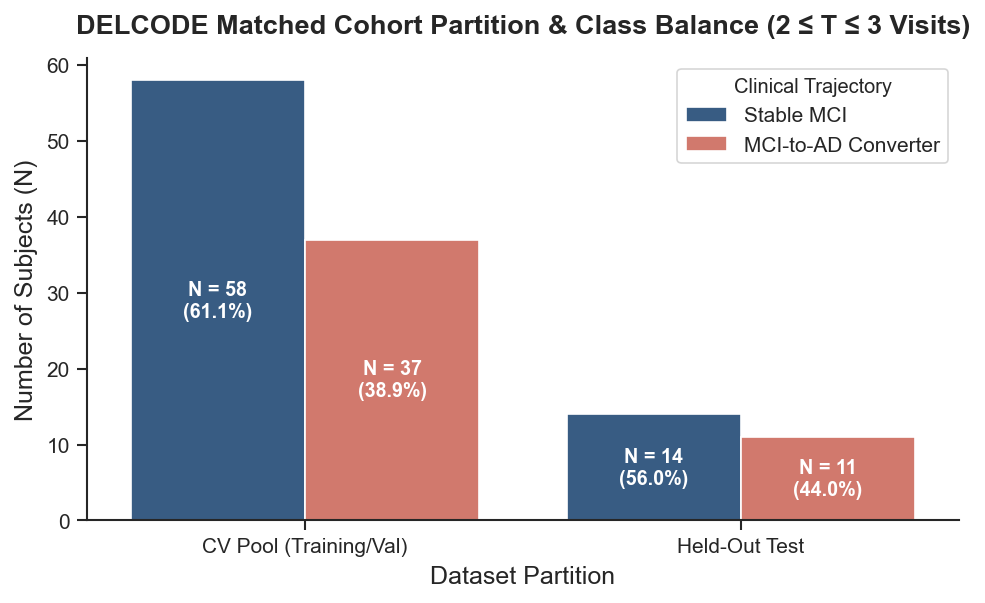

✓ Figure 0 generated and saved.


In [2]:
# Cohort Composition & Demographics Summary
cohort_summary = {
    "Partition": ["CV Pool (Training/Val)", "CV Pool (Training/Val)", "Held-Out Test", "Held-Out Test"],
    "Cohort Group": ["Stable MCI", "MCI-to-AD Converter", "Stable MCI", "MCI-to-AD Converter"],
    "Subject Count (N)": [58, 37, 14, 11],
    "Percentage (%)": [61.1, 38.9, 56.0, 44.0],
    "Visit Window": ["2 ≤ T ≤ 3", "2 ≤ T ≤ 3", "2 ≤ T ≤ 3", "2 ≤ T ≤ 3"]
}
df_cohort = pd.DataFrame(cohort_summary)

# Plot Cohort Class Balance
fig, ax = plt.subplots(figsize=(7.5, 4))
sns.barplot(
    data=df_cohort,
    x="Partition",
    y="Subject Count (N)",
    hue="Cohort Group",
    palette=["#2b5c8f", "#e26d5c"],
    ax=ax
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        total = 95 if p.get_x() < 0.5 else 25
        ax.annotate(f"N = {int(h)}\n({h/total*100:.1f}%)",
                    (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)

ax.set_title("DELCODE Matched Cohort Partition & Class Balance (2 ≤ T ≤ 3 Visits)", pad=12, fontweight="bold")
ax.set_ylabel("Number of Subjects (N)")
ax.set_xlabel("Dataset Partition")
ax.legend(title="Clinical Trajectory", frameon=True)
sns.despine(top=True, right=True)

# Save figure
fig_path = os.path.join(FIGURES_DIR, "fig0_cohort_design_and_distribution.pdf")
plt.savefig(fig_path)
plt.savefig(fig_path.replace(".pdf", ".png"))
plt.show()

print("✓ Figure 0 generated and saved.")


## 2. Multi-Seed Benchmark Data Ingestion & Results Aggregation

We ingest **every completed run** found on disk for each of the 8 registered experiment
ids (one id per seed, per model) — not one hardcoded path per seed. The previous version of
this notebook hardcoded a single run path per seed; seed 42 alone had 7 completed
BrainTokenGT runs on disk and the hardcoded path picked whichever one happened to run last
(see `STABILITY_AUDIT.md` Finding 1). Runs are additionally filtered to one consistent git
commit — pooling across commits conflates code changes with seed effects (`STABILITY_AUDIT.md`
Finding 2, point 2). Run counts are printed by the next cell, computed live, so this table
cannot silently go stale again:

- **GELSTM (Frozen GAAE, 2-3v)**: `CLASSIFIER/outputs/recon-ablation-gelstm-pretrained-frozen-2to3v-seed{42,43,44,45}`
- **BrainTokenGT (Stabilized EvolveGCN-H, 2-3v)**: `BRAINTOKENGT/outputs/braintokengt-delcode-whole-brain-repaired-fix-stabilized{,-seed43,-seed44,-seed45}`


In [3]:
# Discover and ingest ALL runs for each experiment id (not one hardcoded path per
# seed) — see STABILITY_AUDIT.md Finding 1: seed 42 alone had 7 completed runs on
# disk and the original version of this cell picked whichever one ran last.
import glob
from collections import Counter, defaultdict

GELSTM_IDS = {
    42: "recon-ablation-gelstm-pretrained-frozen-2to3v-seed42",
    43: "recon-ablation-gelstm-pretrained-frozen-2to3v-seed43",
    44: "recon-ablation-gelstm-pretrained-frozen-2to3v-seed44",
    45: "recon-ablation-gelstm-pretrained-frozen-2to3v-seed45",
}
BT_IDS = {
    42: "braintokengt-delcode-whole-brain-repaired-fix-stabilized",
    43: "braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed43",
    44: "braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed44",
    45: "braintokengt-delcode-whole-brain-repaired-fix-stabilized-seed45",
}
seeds = [42, 43, 44, 45]


def glob_run_summaries(root, exp_id):
    pattern = os.path.join(root, "outputs", exp_id, "runs", "*", "run_summary.json")
    found = []
    for p in sorted(glob.glob(pattern)):
        try:
            with open(p) as f:
                data = json.load(f)
        except (OSError, json.JSONDecodeError):
            continue  # e.g. an interrupted run that never wrote run_summary.json
        found.append((p, data))
    return found


gelstm_by_seed = {s: glob_run_summaries(os.path.join(PROJECT_ROOT, "CLASSIFIER"), eid)
                   for s, eid in GELSTM_IDS.items()}
bt_by_seed = {s: glob_run_summaries(os.path.join(PROJECT_ROOT, "BRAINTOKENGT"), eid)
              for s, eid in BT_IDS.items()}

# Filter to one consistent commit — the commit shared by the large majority of runs
# found on disk. Not filtering on the recorded 'dirty' flag: many of these repeat
# runs were launched back-to-back without an intervening commit, and STABILITY_AUDIT.md
# Finding 1's 19-run distribution does not filter on it either — commit identity is
# what prevents conflating code changes with seed effects (Finding 2), a dirty
# working tree at launch time is not evidence of that on its own.
commit_counts = Counter()
for by_seed in (gelstm_by_seed, bt_by_seed):
    for runs in by_seed.values():
        for _, data in runs:
            commit_counts[data["git"]["short_commit"]] += 1
REFERENCE_COMMIT = commit_counts.most_common(1)[0][0]


def filter_to_commit(by_seed, commit):
    kept, dropped = defaultdict(list), []
    for seed, runs in by_seed.items():
        for path, data in runs:
            if data["git"]["short_commit"] == commit:
                kept[seed].append((path, data))
            else:
                dropped.append((seed, os.path.basename(os.path.dirname(path)),
                                 data["git"]["short_commit"]))
    return kept, dropped


gelstm_kept, gelstm_dropped = filter_to_commit(gelstm_by_seed, REFERENCE_COMMIT)
bt_kept, bt_dropped = filter_to_commit(bt_by_seed, REFERENCE_COMMIT)

print(f"Reference commit: {REFERENCE_COMMIT}")
print(f"GELSTM runs kept: {sum(len(v) for v in gelstm_kept.values())}  (dropped: {gelstm_dropped or 'none'})")
print(f"BrainTokenGT runs kept: {sum(len(v) for v in bt_kept.values())}  "
      f"(per seed: {({s: len(v) for s, v in bt_kept.items()})})")
if bt_dropped:
    print(f"BrainTokenGT runs excluded by the commit/dirty filter: {bt_dropped}")

# GELSTM (frozen encoder): exactly one completed run per seed exists for this arm
# at the reference commit.
gelstm_runs, seed_records = [], []
for seed in seeds:
    runs = gelstm_kept[seed]
    if len(runs) != 1:
        raise ValueError(
            f"expected exactly 1 GELSTM run at {REFERENCE_COMMIT} for seed {seed}, found {len(runs)}"
        )
    _, g_data = runs[0]
    gelstm_runs.append(g_data)
    seed_records.append({
        "Seed": seed,
        "GELSTM Test AUC": g_data["metrics"]["test_auc"],
        "GELSTM Test F1": g_data["metrics"]["test_f1"],
        "GELSTM CV AUC": np.mean(g_data["cv_results"]["val_auc"]),
        "GELSTM Sens": g_data["metrics"]["test_sensitivity"],
        "GELSTM Spec": g_data["metrics"]["test_specificity"],
        "GELSTM Brier": brier_score_loss(g_data["test_labels"], g_data["test_probabilities"]),
        "GELSTM Threshold": g_data["metrics"]["threshold"],
    })
df_seeds = pd.DataFrame(seed_records)

# BrainTokenGT (stabilized): every completed run at the reference commit is kept.
# This is the point of Finding 1 — averaging away the repeats is what produced the
# false "stabilized" claim in the first place.
bt_run_records = []
bt_runs_by_seed = {}
bt_runs_flat = []
for seed in seeds:
    seed_runs = [d for _, d in bt_kept[seed]]
    bt_runs_by_seed[seed] = seed_runs
    bt_runs_flat.extend(seed_runs)
    for path, b_data in bt_kept[seed]:
        bt_run_records.append({
            "Seed": seed,
            "Run": os.path.basename(os.path.dirname(path)),
            "Test AUC": b_data["metrics"]["test_auc"],
            "Test F1": b_data["metrics"]["test_f1"],
            "CV AUC": np.mean(b_data["cv_results"]["val_auc"]),
            "Sens": b_data["metrics"]["test_sensitivity"],
            "Spec": b_data["metrics"]["test_specificity"],
            "Brier": brier_score_loss(b_data["test_labels"], b_data["test_probabilities"]),
        })
df_bt_runs = pd.DataFrame(bt_run_records)

bt_seed_agg = df_bt_runs.groupby("Seed").agg(**{
    "BrainTokenGT Test AUC": ("Test AUC", "mean"),
    "BrainTokenGT n runs": ("Test AUC", "size"),
    "BrainTokenGT Test F1": ("Test F1", "mean"),
    "BrainTokenGT CV AUC": ("CV AUC", "mean"),
    "BrainTokenGT Sens": ("Sens", "mean"),
    "BrainTokenGT Spec": ("Spec", "mean"),
    "BrainTokenGT Brier": ("Brier", "mean"),
}).reset_index()
df_seeds = df_seeds.merge(bt_seed_agg, on="Seed")

# Fold-level table, kept ONLY for the descriptive CV boxplot (Figure 1A) — folds
# within a run are not independent draws, so no significance test runs on this.
fold_records = []
for i, seed in enumerate(seeds):
    g_data = gelstm_runs[i]
    for fold_idx in range(5):
        fold_records.append({"Seed": seed, "Fold": fold_idx + 1, "Model": "GELSTM (Frozen GAAE, 2-3v)",
                              "CV Val AUC": g_data["cv_results"]["val_auc"][fold_idx]})
    for b_data in bt_runs_by_seed[seed]:
        for fold_idx in range(5):
            fold_records.append({"Seed": seed, "Fold": fold_idx + 1, "Model": "BrainTokenGT (Stabilized, 2-3v)",
                                  "CV Val AUC": b_data["cv_results"]["val_auc"][fold_idx]})
df_folds = pd.DataFrame(fold_records)

display_cols = ["Seed", "GELSTM Test AUC", "GELSTM Test F1", "GELSTM CV AUC",
                 "BrainTokenGT n runs", "BrainTokenGT Test AUC", "BrainTokenGT Test F1", "BrainTokenGT CV AUC"]
print("\n=== SEED-BY-SEED (BrainTokenGT columns are MEANS of every repeat run at the reference commit) ===")
display(df_seeds[display_cols].style.format(
    "{:.4f}", subset=[c for c in display_cols[1:] if c != "BrainTokenGT n runs"]
).set_caption(f"Seed-by-Seed Performance @ commit {REFERENCE_COMMIT} (Matched Cohort, 2 \u2264 T \u2264 3)"))

print("\n=== ALL BRAINTOKENGT RUNS, run-level (not seed-collapsed) ===")
display(df_bt_runs.style.format("{:.4f}", subset=["Test AUC", "Test F1", "CV AUC", "Sens", "Spec", "Brier"]))


Reference commit: 5e33e2170
GELSTM runs kept: 4  (dropped: none)
BrainTokenGT runs kept: 18  (per seed: {42: 6, 43: 4, 44: 4, 45: 4})
BrainTokenGT runs excluded by the commit/dirty filter: [(42, 'worthy-shape-1-20b595788-2026-08-18_19-37-42', '20b595788')]

=== SEED-BY-SEED (BrainTokenGT columns are MEANS of every repeat run at the reference commit) ===


,Seed,GELSTM Test AUC,GELSTM Test F1,GELSTM CV AUC,BrainTokenGT n runs,BrainTokenGT Test AUC,BrainTokenGT Test F1,BrainTokenGT CV AUC
0,42,0.8701,0.5556,0.9600,6,0.6147,0.5090,0.8063
1,43,0.8701,0.7778,0.9551,4,0.6802,0.4476,0.8114
2,44,0.9156,0.7273,0.9645,4,0.5227,0.6329,0.7089
3,45,0.8571,0.7000,0.9598,4,0.6477,0.5605,0.7780



=== ALL BRAINTOKENGT RUNS, run-level (not seed-collapsed) ===


,Seed,Run,Test AUC,Test F1,CV AUC,Sens,Spec,Brier
0,42,crimson-morning-8-5e33e2170-2026-08-21_18-47-20,0.6104,0.5217,0.7666,0.5455,0.5714,0.2905
1,42,jolly-ocean-4-5e33e2170-2026-08-21_12-18-59,0.7078,0.4706,0.8159,0.3636,0.8571,0.3206
2,42,laced-mountain-2-74659c77b-2026-08-21_12-05-40,0.6948,0.4706,0.7987,0.3636,0.8571,0.2279
3,42,twilight-sky-5-5e33e2170-2026-08-21_12-21-37,0.5519,0.4800,0.7667,0.5455,0.4286,0.2352
4,42,twilight-stone-7-5e33e2170-2026-08-21_12-34-35,0.5714,0.6111,0.8242,1.0000,0.0000,0.2681
5,42,winter-mountain-3-74659c77b-2026-08-21_12-06-57,0.5519,0.5000,0.8657,0.5455,0.5000,0.3658
6,43,eager-feather-4-5e33e2170-2026-08-22_11-39-02,0.6364,0.4444,0.8451,0.3636,0.7857,0.3092
7,43,morning-dream-2-5e33e2170-2026-08-22_11-03-16,0.6883,0.4211,0.8172,0.3636,0.7143,0.3863
8,43,ruby-cloud-1-5e33e2170-2026-08-21_19-02-53,0.8182,0.6897,0.7794,0.9091,0.4286,0.1762
9,43,winter-zenith-3-5e33e2170-2026-08-22_11-28-58,0.5779,0.2353,0.8038,0.1818,0.7143,0.2337


## 3. Statistical Comparison & Reproducibility

### 3.1 What changed and why (`STABILITY_AUDIT.md` Finding 1, `SUBMISSION_RUNWAY.md` Phase B1)

The previous version of this section ran three significance tests, all invalid for this
data:

1. A paired *t*-test on 4 seed-level test-AUC values, treating seed as the only source of
   variance. It isn't, for BrainTokenGT — see the reproducibility contrast below.
2. A paired *t*-test on 20 fold-level CV-AUC values, treating folds as independent samples.
   Folds within one 5-fold run share training data and are not independent — **this test is
   removed, not replaced.** The CV-fold panel below (Figure 1A) is descriptive only.
3. The same paired *t*-test repeated on test-F1.

What replaces them:

- **A Wilcoxon signed-rank test on the 4 seed-paired test-AUC/F1 values** — non-parametric,
  but still only n=4 pairs, reported as underpowered by construction (minimum attainable
  two-sided p at n=4 is 0.125).
- **A seed-cluster bootstrap 95% CI on the mean margin**, resampling seeds with replacement
  and, for each resampled seed, resampling one BrainTokenGT run from *its own repeats* —
  this propagates BrainTokenGT's within-seed run-to-run noise into the interval instead of
  discarding it, which a seed-only bootstrap would do.
- **A reproducibility contrast as a result in its own right**, not a caveat: within-seed SD
  vs. between-seed SD for BrainTokenGT, and a note on GELSTM's separately-verified
  byte-reproducibility (D2 gate).


=== STATISTICAL COMPARISON (non-parametric, seed-paired) ===


,Metric,"GELSTM (Frozen GAAE, 2–3v)","BrainTokenGT (Stabilized, 2–3v)",Margin (Δ),Inference
0,"Held-Out Test AUC (seed means, n=4 pairs)",0.8782 ± 0.0256,0.6163 ± 0.0679,+0.2619,"Wilcoxon p=0.1250 (n=4, underpowered); 95% seed-cluster boot. CI [+0.1575, +0.3750]"
1,"Held-Out Test F1 (seed means, n=4 pairs)",0.6902 ± 0.0953,0.5375 ± 0.0786,+0.1526,"Wilcoxon p=0.1250 (n=4, underpowered)"



=== REPRODUCIBILITY CONTRAST (bit/run-level result, not a caveat) ===


,Model,Repeats per seed (this arm),Within-seed SD,Note
0,GELSTM (Frozen GAAE),1 (0 repeats),n/a — no repeats in this arm,"Determinism verified on the sibling `recon-ablation-gelstm-none` id: run_summary.json reruns byte-identical at a fixed seed (D2 gate, SUBMISSION_RUNWAY.md)."
1,BrainTokenGT (Stabilized),"{42: 6, 43: 4, 44: 4, 45: 4}",0.0895 (mean across seeds),"Between-seed-mean SD 0.0679; within-seed SD exceeds it — the 4 ‘seeds’ are largely 4 draws of run-to-run noise, not 4 independent seed effects. Grand mean over all 18 runs: 0.6162 ± 0.0980."


/tmp/ipykernel_46667/1101808569.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_folds, x="Model", y="CV Val AUC", palette=["#1f77b4", "#d62728"],
/tmp/ipykernel_46667/1101808569.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["GELSTM\n(Frozen GAAE)", "BrainTokenGT\n(Stabilized)"])
/tmp/ipykernel_46667/1101808569.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_auc_all, x="Model", y="Test AUC", palette=["#1f77b4", "#d62728"],
/tmp/ipykernel_46667/1101808569.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

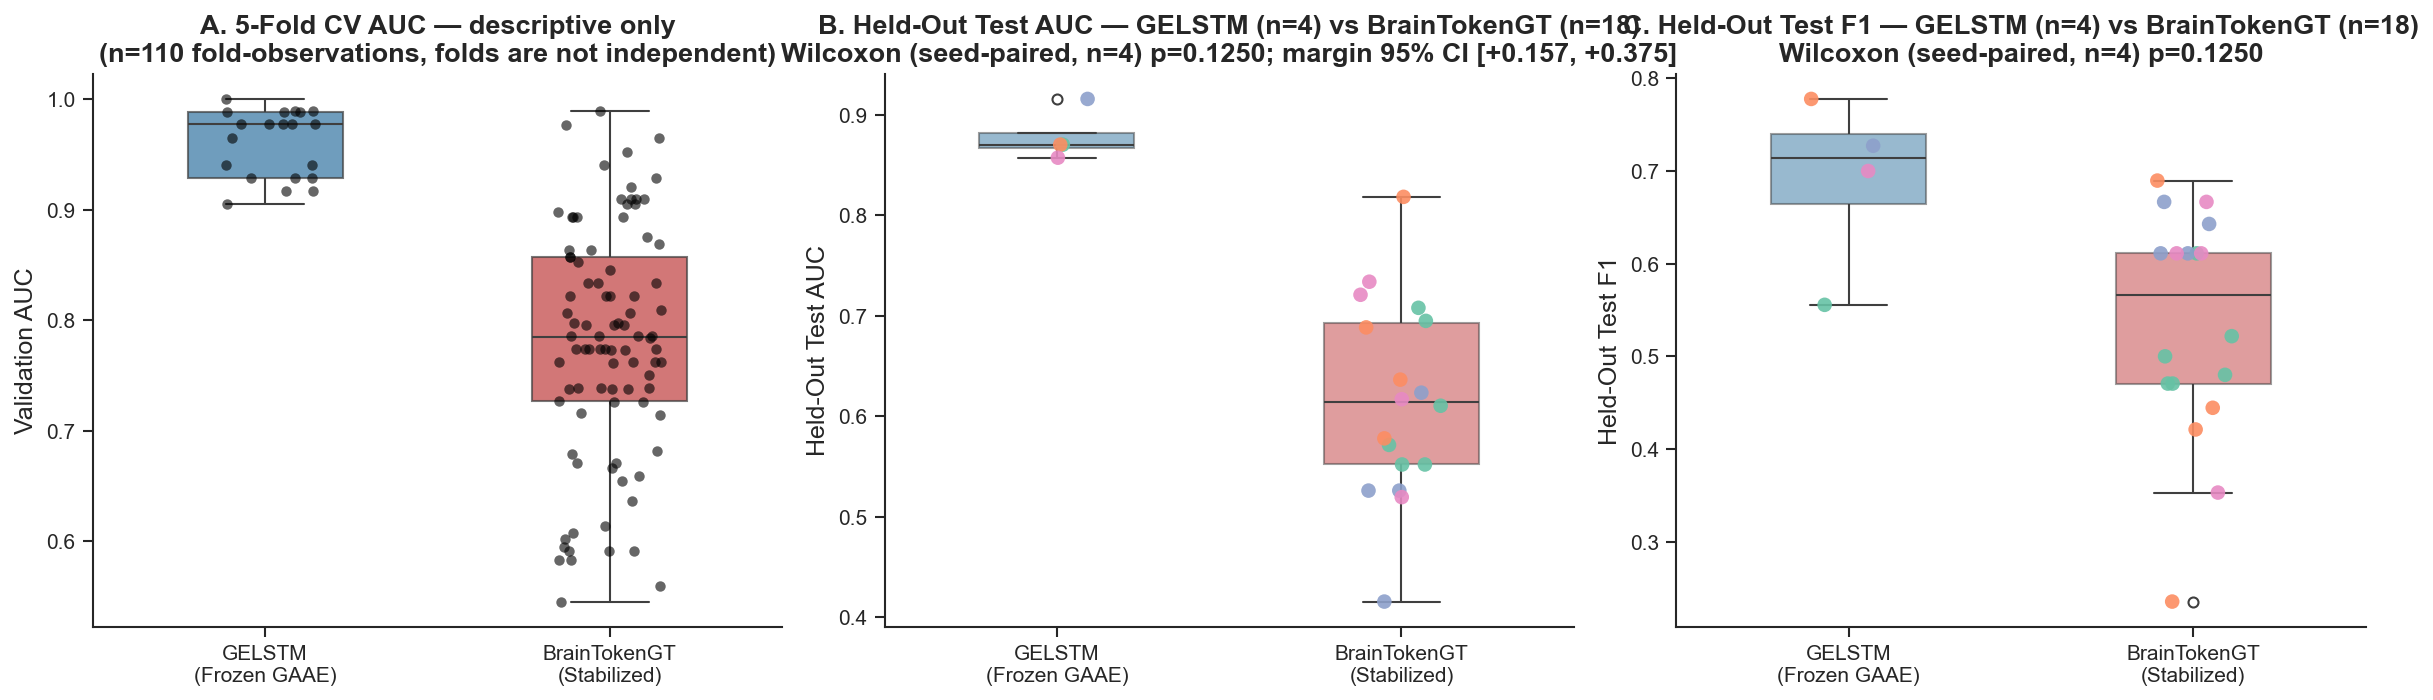

✓ Figure 1 generated (descriptive CV panel; full-distribution AUC/F1 panels, colored by seed).


In [4]:
# Statistical comparison — non-parametric, seed-paired (n=4), plus a seed-cluster
# bootstrap CI that propagates BrainTokenGT's within-seed noise. No test is run on
# the fold-level table (Figure 1A is descriptive only).
g_test_aucs = df_seeds["GELSTM Test AUC"].values
b_test_aucs = df_seeds["BrainTokenGT Test AUC"].values  # seed means, n=4, paired with g_test_aucs
g_test_f1s = df_seeds["GELSTM Test F1"].values
b_test_f1s = df_seeds["BrainTokenGT Test F1"].values

w_test_auc, pw_test_auc = stats.wilcoxon(g_test_aucs, b_test_aucs)
w_test_f1, pw_test_f1 = stats.wilcoxon(g_test_f1s, b_test_f1s)

# Seed-cluster bootstrap on the AUC margin: resample seeds with replacement; for
# each resampled seed, resample one BrainTokenGT run from ITS repeats (with
# replacement). This reflects both between-seed and within-seed variance, unlike
# a plain seed-level bootstrap which would only see the (understated) seed means.
rng = np.random.default_rng(42)
N_BOOT = 5000
bt_auc_by_seed = {s: df_bt_runs.loc[df_bt_runs["Seed"] == s, "Test AUC"].values for s in seeds}
boot_margins = np.empty(N_BOOT)
for b in range(N_BOOT):
    resampled_seeds = rng.choice(seeds, size=4, replace=True)
    g_sample = np.array([g_test_aucs[seeds.index(s)] for s in resampled_seeds])
    b_sample = np.array([rng.choice(bt_auc_by_seed[s]) for s in resampled_seeds])
    boot_margins[b] = g_sample.mean() - b_sample.mean()
ci_lo, ci_hi = np.percentile(boot_margins, [2.5, 97.5])

summary_table = pd.DataFrame([
    {
        "Metric": "Held-Out Test AUC (seed means, n=4 pairs)",
        "GELSTM (Frozen GAAE, 2\u20133v)": f"{g_test_aucs.mean():.4f} \u00b1 {g_test_aucs.std(ddof=1):.4f}",
        "BrainTokenGT (Stabilized, 2\u20133v)": f"{b_test_aucs.mean():.4f} \u00b1 {b_test_aucs.std(ddof=1):.4f}",
        "Margin (\u0394)": f"{g_test_aucs.mean() - b_test_aucs.mean():+.4f}",
        "Inference": f"Wilcoxon p={pw_test_auc:.4f} (n=4, underpowered); 95% seed-cluster boot. CI [{ci_lo:+.4f}, {ci_hi:+.4f}]",
    },
    {
        "Metric": "Held-Out Test F1 (seed means, n=4 pairs)",
        "GELSTM (Frozen GAAE, 2\u20133v)": f"{g_test_f1s.mean():.4f} \u00b1 {g_test_f1s.std(ddof=1):.4f}",
        "BrainTokenGT (Stabilized, 2\u20133v)": f"{b_test_f1s.mean():.4f} \u00b1 {b_test_f1s.std(ddof=1):.4f}",
        "Margin (\u0394)": f"{g_test_f1s.mean() - b_test_f1s.mean():+.4f}",
        "Inference": f"Wilcoxon p={pw_test_f1:.4f} (n=4, underpowered)",
    },
])
print("=== STATISTICAL COMPARISON (non-parametric, seed-paired) ===")
display(summary_table.style.set_caption(f"Statistical Comparison @ commit {REFERENCE_COMMIT}"))

# --- Reproducibility contrast: a result, not a caveat --------------------------
bt_within_seed_sd = df_bt_runs.groupby("Seed")["Test AUC"].std(ddof=1)
bt_between_seed_sd = df_bt_runs.groupby("Seed")["Test AUC"].mean().std(ddof=1)
bt_grand_mean = df_bt_runs["Test AUC"].mean()
bt_grand_sd = df_bt_runs["Test AUC"].std(ddof=1)
repro_table = pd.DataFrame([
    {
        "Model": "GELSTM (Frozen GAAE)",
        "Repeats per seed (this arm)": "1 (0 repeats)",
        "Within-seed SD": "n/a \u2014 no repeats in this arm",
        "Note": "Determinism verified on the sibling `recon-ablation-gelstm-none` id: run_summary.json "
                "reruns byte-identical at a fixed seed (D2 gate, SUBMISSION_RUNWAY.md).",
    },
    {
        "Model": "BrainTokenGT (Stabilized)",
        "Repeats per seed (this arm)": str(dict(df_bt_runs["Seed"].value_counts().sort_index())),
        "Within-seed SD": f"{bt_within_seed_sd.mean():.4f} (mean across seeds)",
        "Note": f"Between-seed-mean SD {bt_between_seed_sd:.4f}; within-seed SD "
                f"{'exceeds' if bt_within_seed_sd.mean() > bt_between_seed_sd else 'is comparable to'} it \u2014 "
                f"the 4 \u2018seeds\u2019 are largely 4 draws of run-to-run noise, not 4 independent seed effects. "
                f"Grand mean over all {len(df_bt_runs)} runs: {bt_grand_mean:.4f} \u00b1 {bt_grand_sd:.4f}.",
    },
])
print("\n=== REPRODUCIBILITY CONTRAST (bit/run-level result, not a caveat) ===")
display(repro_table.style.set_caption("GELSTM verified byte-reproducible; BrainTokenGT is not, at a fixed seed"))

# -------------------------------------------------------------
# FIGURE 1: Distributions. Panel A is descriptive only (no significance test on
# non-independent folds). Panels B/C show every run, not just seed means, so
# BrainTokenGT\'s within-seed spread is visible instead of averaged away.
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.boxplot(data=df_folds, x="Model", y="CV Val AUC", palette=["#1f77b4", "#d62728"],
            width=0.45, ax=axes[0], boxprops=dict(alpha=0.7))
sns.stripplot(data=df_folds, x="Model", y="CV Val AUC", color="black", size=5, jitter=0.15, alpha=0.6, ax=axes[0])
axes[0].set_title(f"A. 5-Fold CV AUC \u2014 descriptive only\n(n={len(df_folds)} fold-observations, folds are not independent)", fontweight="bold")
axes[0].set_ylabel("Validation AUC")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["GELSTM\n(Frozen GAAE)", "BrainTokenGT\n(Stabilized)"])

df_auc_all = pd.concat([
    pd.DataFrame({"Model": "GELSTM", "Seed": seeds, "Test AUC": g_test_aucs}),
    df_bt_runs.rename(columns={"Test AUC": "Test AUC"})[["Seed", "Test AUC"]].assign(Model="BrainTokenGT"),
], ignore_index=True)
sns.boxplot(data=df_auc_all, x="Model", y="Test AUC", palette=["#1f77b4", "#d62728"],
            width=0.45, ax=axes[1], boxprops=dict(alpha=0.5))
sns.stripplot(data=df_auc_all, x="Model", y="Test AUC", hue="Seed", palette="Set2",
              size=7, jitter=0.12, alpha=0.9, ax=axes[1], legend=False)
axes[1].set_title(f"B. Held-Out Test AUC \u2014 GELSTM (n=4) vs BrainTokenGT (n={len(df_bt_runs)})\n"
                   f"Wilcoxon (seed-paired, n=4) p={pw_test_auc:.4f}; margin 95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}]",
                   fontweight="bold")
axes[1].set_ylabel("Held-Out Test AUC")
axes[1].set_xlabel("")

df_f1_all = pd.concat([
    pd.DataFrame({"Model": "GELSTM", "Seed": seeds, "Test F1": g_test_f1s}),
    df_bt_runs.rename(columns={"Test F1": "Test F1"})[["Seed", "Test F1"]].assign(Model="BrainTokenGT"),
], ignore_index=True)
sns.boxplot(data=df_f1_all, x="Model", y="Test F1", palette=["#1f77b4", "#d62728"],
            width=0.45, ax=axes[2], boxprops=dict(alpha=0.5))
sns.stripplot(data=df_f1_all, x="Model", y="Test F1", hue="Seed", palette="Set2",
              size=7, jitter=0.12, alpha=0.9, ax=axes[2], legend=False)
axes[2].set_title(f"C. Held-Out Test F1 \u2014 GELSTM (n=4) vs BrainTokenGT (n={len(df_bt_runs)})\n"
                   f"Wilcoxon (seed-paired, n=4) p={pw_test_f1:.4f}", fontweight="bold")
axes[2].set_ylabel("Held-Out Test F1")
axes[2].set_xlabel("")
for ax in axes[1:]:
    ax.set_xticklabels(["GELSTM\n(Frozen GAAE)", "BrainTokenGT\n(Stabilized)"])

sns.despine(top=True, right=True)
plt.tight_layout()
fig1_path = os.path.join(FIGURES_DIR, "fig1_cv_and_test_distributions.pdf")
plt.savefig(fig1_path)
plt.savefig(fig1_path.replace(".pdf", ".png"))
plt.show()

print("\u2713 Figure 1 generated (descriptive CV panel; full-distribution AUC/F1 panels, colored by seed).")


## 4. Discriminative Power: ROC & Precision-Recall Analysis

### 4.1 Why Precision-Recall Curves Matter in Alzheimer's Prognosis
While the **Receiver Operating Characteristic (ROC)** curve provides a global overview of true-positive vs. false-positive trade-offs across all operating points, it can overestimate performance in imbalanced clinical cohorts. The **Precision-Recall (PR)** curve directly evaluates positive predictive value (Precision) against clinical sensitivity (Recall), exposing diagnostic false alarms.

Here we plot multi-seed ROC and PR curves using Scikit-Learn's standard displays alongside aggregated mean performance bands with $\pm 1$ standard deviation confidence ribbons.


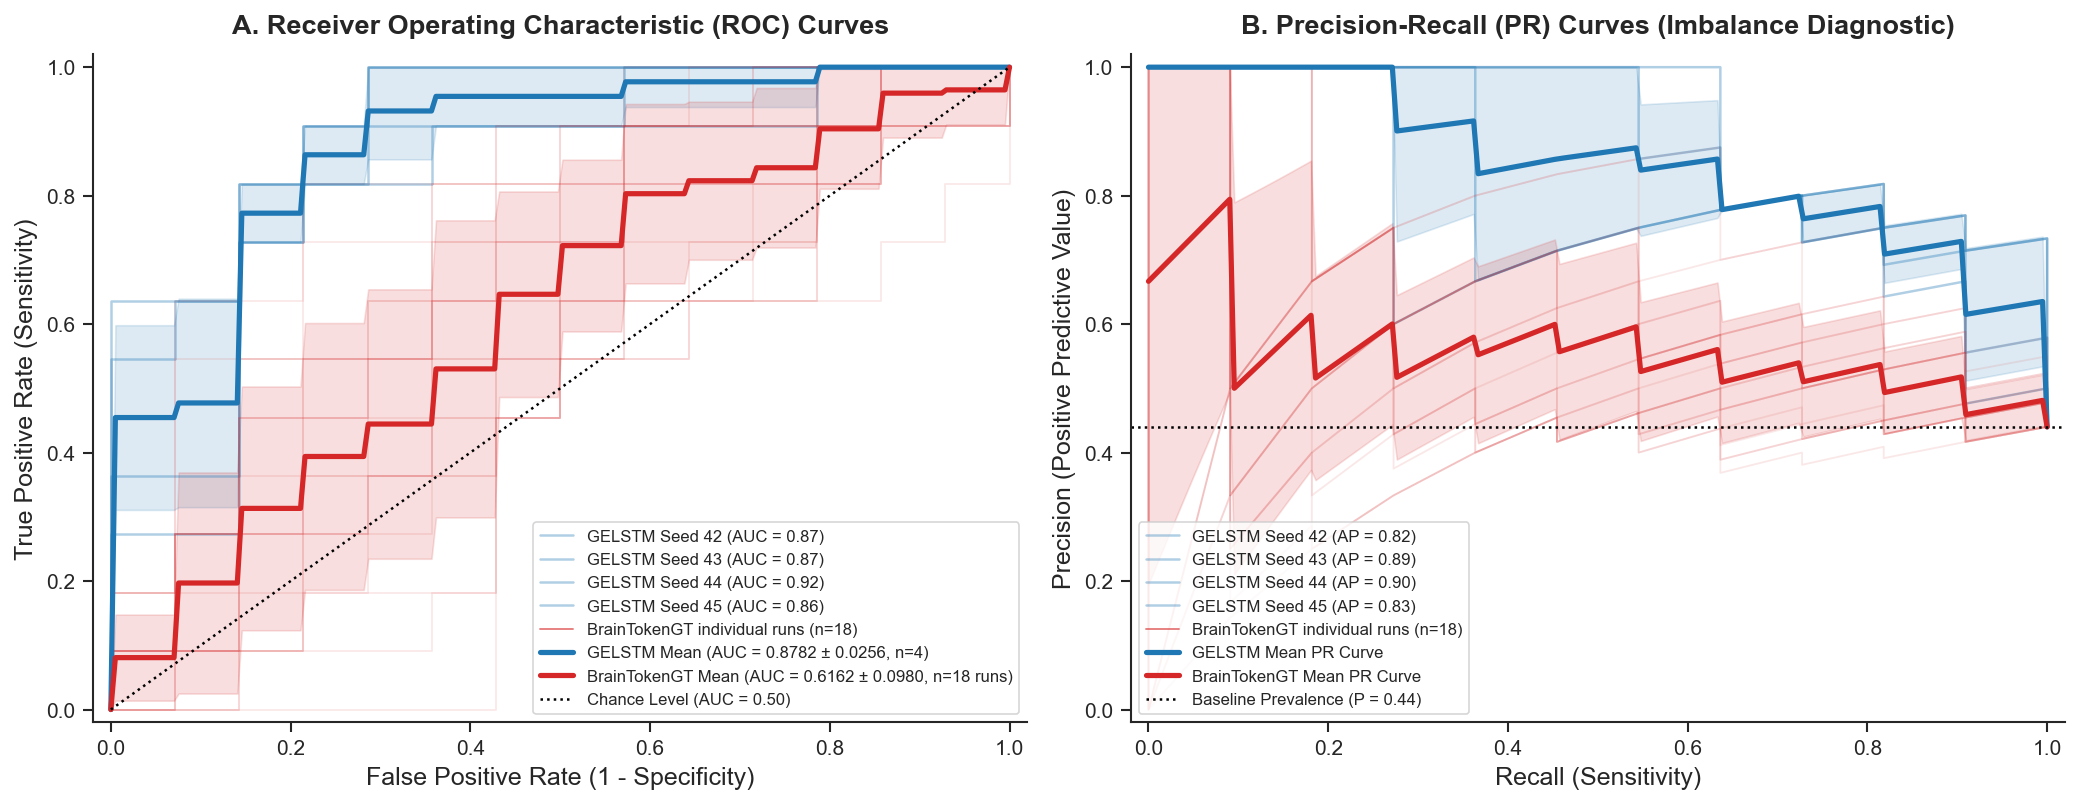

✓ Figure 2 generated (BrainTokenGT band now reflects run-to-run spread, not just seed spread).


In [5]:
# -------------------------------------------------------------
# FIGURE 2: Multi-Seed ROC and Precision-Recall Curves
# BrainTokenGT now has multiple runs per seed; every individual run is plotted
# faint (a single proxy legend entry, not one per run, to keep the legend
# readable), and the mean curve is computed over all runs, not seed means.
# -------------------------------------------------------------
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5.5))

mean_fpr = np.linspace(0, 1, 200)
mean_recall = np.linspace(0, 1, 200)

g_tprs, g_precisions = [], []
for i, seed in enumerate(seeds):
    y_true_g = gelstm_runs[i]["test_labels"]
    y_prob_g = gelstm_runs[i]["test_probabilities"]
    fpr_g, tpr_g, _ = roc_curve(y_true_g, y_prob_g)
    roc_auc_g = auc(fpr_g, tpr_g)
    interp_tpr_g = np.interp(mean_fpr, fpr_g, tpr_g)
    interp_tpr_g[0] = 0.0
    g_tprs.append(interp_tpr_g)

    prec_g, rec_g, _ = precision_recall_curve(y_true_g, y_prob_g)
    ap_g = average_precision_score(y_true_g, y_prob_g)
    g_precisions.append(np.interp(mean_recall, rec_g[::-1], prec_g[::-1]))

    ax_roc.plot(fpr_g, tpr_g, color="#1f77b4", alpha=0.35, lw=1.2,
                label=f"GELSTM Seed {seed} (AUC = {roc_auc_g:.2f})")
    ax_pr.plot(rec_g, prec_g, color="#1f77b4", alpha=0.35, lw=1.2,
               label=f"GELSTM Seed {seed} (AP = {ap_g:.2f})")

b_tprs, b_precisions = [], []
for b_data in bt_runs_flat:
    y_true_b = b_data["test_labels"]
    y_prob_b = b_data["test_probabilities"]
    fpr_b, tpr_b, _ = roc_curve(y_true_b, y_prob_b)
    interp_tpr_b = np.interp(mean_fpr, fpr_b, tpr_b)
    interp_tpr_b[0] = 0.0
    b_tprs.append(interp_tpr_b)

    prec_b, rec_b, _ = precision_recall_curve(y_true_b, y_prob_b)
    b_precisions.append(np.interp(mean_recall, rec_b[::-1], prec_b[::-1]))

    ax_roc.plot(fpr_b, tpr_b, color="#d62728", alpha=0.10, lw=0.9)
    ax_pr.plot(rec_b, prec_b, color="#d62728", alpha=0.10, lw=0.9)

ax_roc.plot([], [], color="#d62728", alpha=0.6, lw=0.9, label=f"BrainTokenGT individual runs (n={len(bt_runs_flat)})")
ax_pr.plot([], [], color="#d62728", alpha=0.6, lw=0.9, label=f"BrainTokenGT individual runs (n={len(bt_runs_flat)})")

mean_tpr_g = np.mean(g_tprs, axis=0)
mean_tpr_g[-1] = 1.0
std_tpr_g = np.std(g_tprs, axis=0)
ax_roc.plot(mean_fpr, mean_tpr_g, color="#1f77b4", lw=2.5,
            label=f"GELSTM Mean (AUC = {g_test_aucs.mean():.4f} \u00b1 {g_test_aucs.std(ddof=1):.4f}, n=4)")
ax_roc.fill_between(mean_fpr, np.maximum(0, mean_tpr_g - std_tpr_g), np.minimum(1, mean_tpr_g + std_tpr_g),
                    color="#1f77b4", alpha=0.15)

mean_tpr_b = np.mean(b_tprs, axis=0)
mean_tpr_b[-1] = 1.0
std_tpr_b = np.std(b_tprs, axis=0)
bt_pooled_auc_mean = df_bt_runs["Test AUC"].mean()
bt_pooled_auc_sd = df_bt_runs["Test AUC"].std(ddof=1)
ax_roc.plot(mean_fpr, mean_tpr_b, color="#d62728", lw=2.5,
            label=f"BrainTokenGT Mean (AUC = {bt_pooled_auc_mean:.4f} \u00b1 {bt_pooled_auc_sd:.4f}, n={len(bt_runs_flat)} runs)")
ax_roc.fill_between(mean_fpr, np.maximum(0, mean_tpr_b - std_tpr_b), np.minimum(1, mean_tpr_b + std_tpr_b),
                    color="#d62728", alpha=0.15)

ax_roc.plot([0, 1], [0, 1], linestyle=":", color="black", lw=1.2, label="Chance Level (AUC = 0.50)")
ax_roc.set_xlim([-0.02, 1.02])
ax_roc.set_ylim([-0.02, 1.02])
ax_roc.set_xlabel("False Positive Rate (1 - Specificity)")
ax_roc.set_ylabel("True Positive Rate (Sensitivity)")
ax_roc.set_title("A. Receiver Operating Characteristic (ROC) Curves", pad=10, fontweight="bold")
ax_roc.legend(loc="lower right", fontsize=8, frameon=True)

mean_prec_g = np.mean(g_precisions, axis=0)
std_prec_g = np.std(g_precisions, axis=0)
ax_pr.plot(mean_recall, mean_prec_g, color="#1f77b4", lw=2.5, label="GELSTM Mean PR Curve")
ax_pr.fill_between(mean_recall, np.maximum(0, mean_prec_g - std_prec_g), np.minimum(1, mean_prec_g + std_prec_g),
                   color="#1f77b4", alpha=0.15)

mean_prec_b = np.mean(b_precisions, axis=0)
std_prec_b = np.std(b_precisions, axis=0)
ax_pr.plot(mean_recall, mean_prec_b, color="#d62728", lw=2.5, label="BrainTokenGT Mean PR Curve")
ax_pr.fill_between(mean_recall, np.maximum(0, mean_prec_b - std_prec_b), np.minimum(1, mean_prec_b + std_prec_b),
                   color="#d62728", alpha=0.15)

prevalence = 11.0 / 25.0
ax_pr.axhline(prevalence, color="black", linestyle=":", lw=1.2, label=f"Baseline Prevalence (P = {prevalence:.2f})")
ax_pr.set_xlim([-0.02, 1.02])
ax_pr.set_ylim([-0.02, 1.02])
ax_pr.set_xlabel("Recall (Sensitivity)")
ax_pr.set_ylabel("Precision (Positive Predictive Value)")
ax_pr.set_title("B. Precision-Recall (PR) Curves (Imbalance Diagnostic)", pad=10, fontweight="bold")
ax_pr.legend(loc="lower left", fontsize=8, frameon=True)

sns.despine(top=True, right=True)
plt.tight_layout()

fig2_path = os.path.join(FIGURES_DIR, "fig2_roc_and_pr_curves.pdf")
plt.savefig(fig2_path)
plt.savefig(fig2_path.replace(".pdf", ".png"))
plt.show()

print("\u2713 Figure 2 generated (BrainTokenGT band now reflects run-to-run spread, not just seed spread).")


## 5. Diagnostic Thresholds & Confusion Matrix Profiles

### 5.1 Operating Point Calibration in Clinical Practice
In prognostic screening for Alzheimer's disease:
- **False Negatives (FN)** represent high risk: an MCI patient who will convert to Alzheimer's is classified as stable and misses early therapeutic intervention windows.
- **False Positives (FP)** cause emotional distress and unwarranted downstream invasive PET/CSF testing.

Both models determine their decision threshold via out-of-fold validation optimization (Youden Index / F1 maximization). Below, we visualize the complete $4 \times 2$ grid of confusion matrices using Scikit-Learn's `ConfusionMatrixDisplay`.


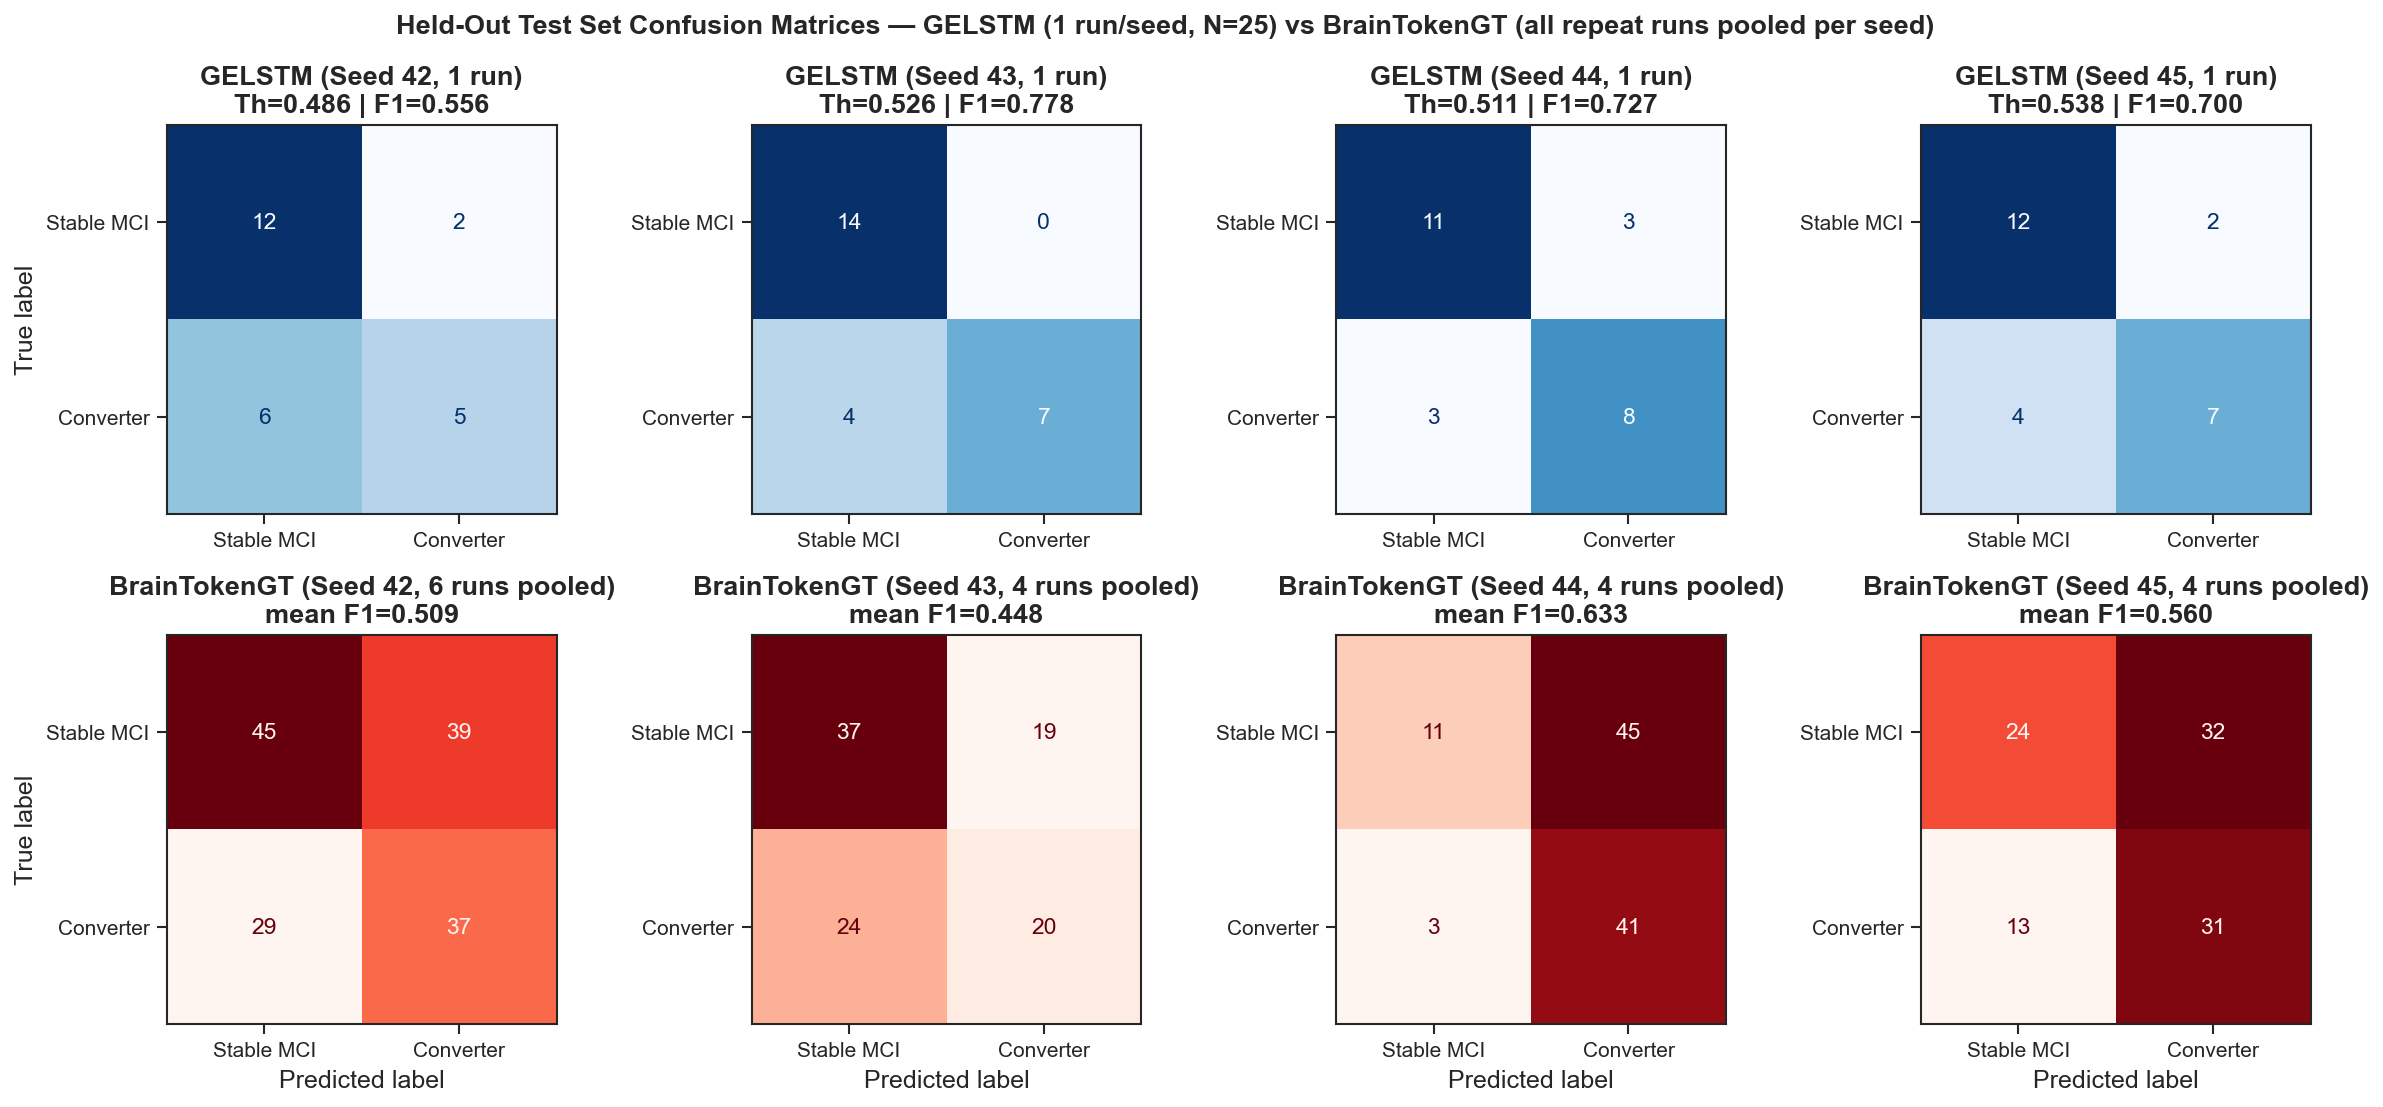

✓ Figure 3 generated (BrainTokenGT panels pool every repeat run per seed, not one cherry-picked run).


In [6]:
# -------------------------------------------------------------
# FIGURE 3: Multi-Seed Confusion Matrix Grid (4 Seeds x 2 Models)
# BrainTokenGT's row pools predictions across ALL repeat runs for that seed
# (not one cherry-picked run) — this is the honest operating-point picture given
# that a single repeat's confusion matrix is itself a draw from run-to-run noise.
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))

classes = ["Stable MCI", "Converter"]

for i, seed in enumerate(seeds):
    y_true_g = np.array(gelstm_runs[i]["test_labels"])
    y_prob_g = np.array(gelstm_runs[i]["test_probabilities"])
    th_g = gelstm_runs[i]["metrics"]["threshold"]
    y_pred_g = (y_prob_g >= th_g).astype(int)
    cm_g = confusion_matrix(y_true_g, y_pred_g)

    disp_g = ConfusionMatrixDisplay(confusion_matrix=cm_g, display_labels=classes)
    disp_g.plot(ax=axes[0, i], cmap="Blues", colorbar=False)
    axes[0, i].set_title(f"GELSTM (Seed {seed}, 1 run)\nTh={th_g:.3f} | F1={df_seeds.loc[i, 'GELSTM Test F1']:.3f}", fontweight="bold")
    if i > 0:
        axes[0, i].set_ylabel("")
    axes[0, i].set_xlabel("")

    seed_bt_runs = bt_runs_by_seed[seed]
    y_true_b = np.concatenate([np.array(r["test_labels"]) for r in seed_bt_runs])
    y_pred_b = np.concatenate([
        (np.array(r["test_probabilities"]) >= r["metrics"]["threshold"]).astype(int) for r in seed_bt_runs
    ])
    cm_b = confusion_matrix(y_true_b, y_pred_b)
    mean_f1_b = df_bt_runs.loc[df_bt_runs["Seed"] == seed, "Test F1"].mean()

    disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=classes)
    disp_b.plot(ax=axes[1, i], cmap="Reds", colorbar=False)
    axes[1, i].set_title(f"BrainTokenGT (Seed {seed}, {len(seed_bt_runs)} runs pooled)\nmean F1={mean_f1_b:.3f}", fontweight="bold")
    if i > 0:
        axes[1, i].set_ylabel("")

plt.suptitle(f"Held-Out Test Set Confusion Matrices \u2014 GELSTM (1 run/seed, N={len(gelstm_runs[0]['test_labels'])}) "
             f"vs BrainTokenGT (all repeat runs pooled per seed)", fontsize=13, y=0.98, fontweight="bold")
plt.tight_layout()

fig3_path = os.path.join(FIGURES_DIR, "fig3_confusion_matrices.pdf")
plt.savefig(fig3_path)
plt.savefig(fig3_path.replace(".pdf", ".png"))
plt.show()

print("\u2713 Figure 3 generated (BrainTokenGT panels pool every repeat run per seed, not one cherry-picked run).")


## 6. Probability Calibration & Reliability Analysis

### 6.1 Clinical Utility of Well-Calibrated Probabilities
In medical decision support systems, a raw binary classification is rarely sufficient. Clinicians need well-calibrated probabilities $P(\text{Converter} \mid \mathbf{X})$ to stratify patient risk and schedule follow-up intervals.

A model with a low **Brier Score** ($BS = \frac{1}{N} \sum (p_i - y_i)^2$) and a calibration curve hugging the $45^\circ$ diagonal provides trustworthy probabilities.


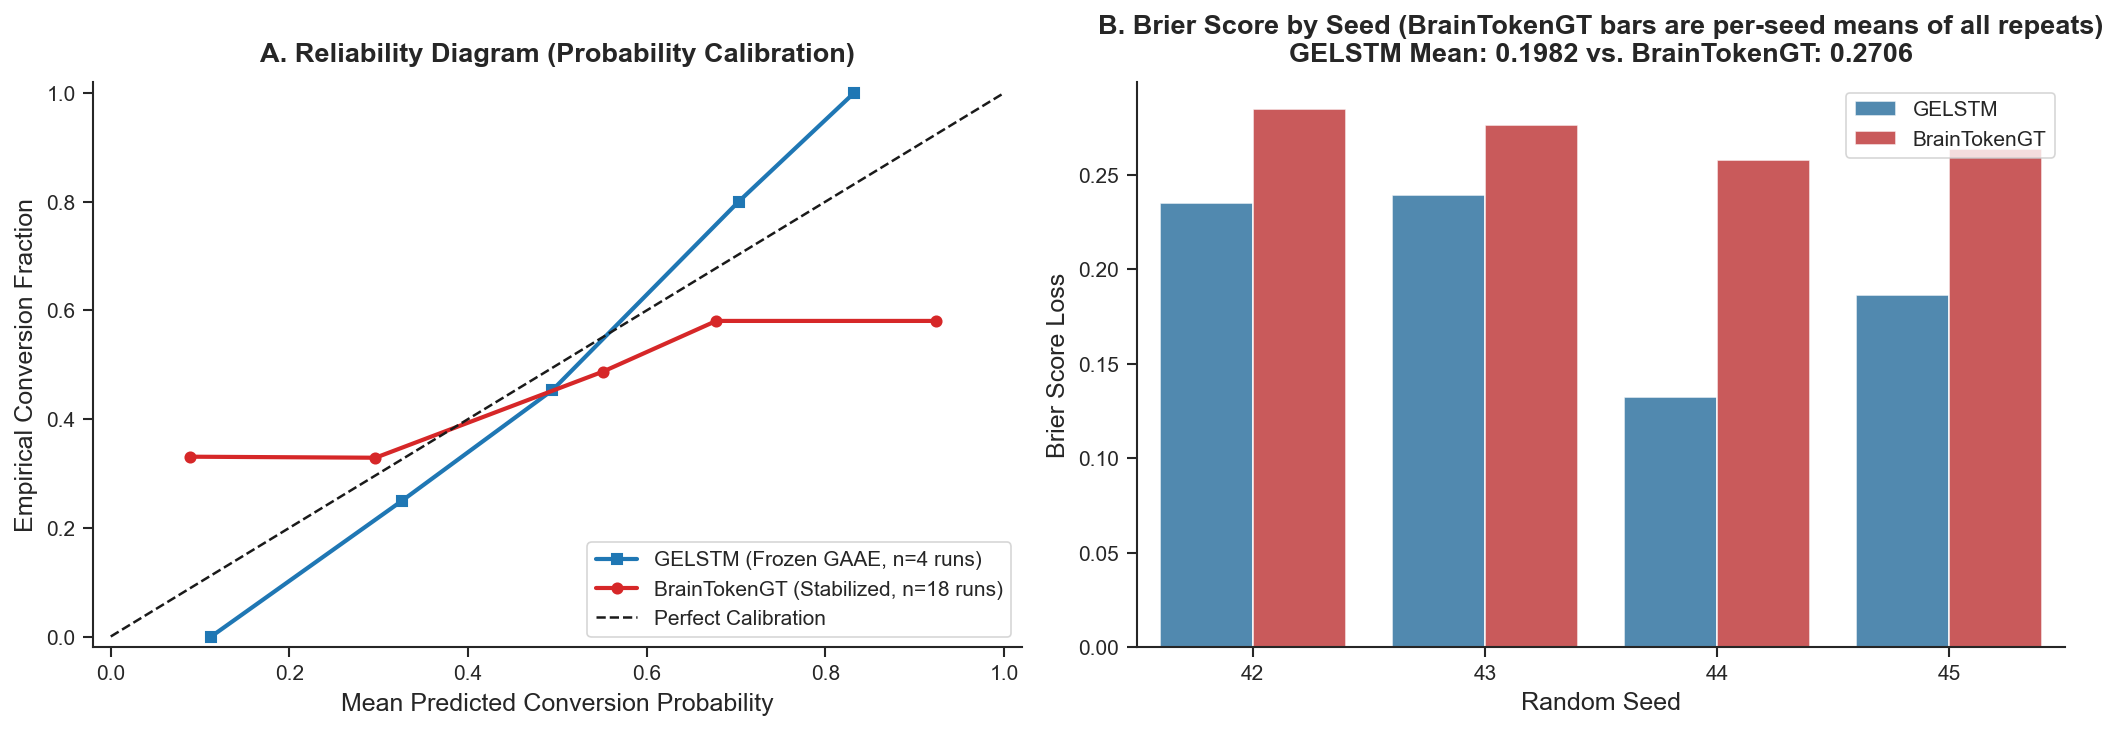

✓ Figure 4 generated (calibration pools every repeat run; Brier bars are per-seed means).


In [7]:
# -------------------------------------------------------------
# FIGURE 4: Probability Calibration & Brier Score Comparison
# Calibration curves pool ALL BrainTokenGT repeat runs (bt_runs_flat), not one
# per seed, so a single lucky/unlucky run cannot dominate the reliability curve.
# -------------------------------------------------------------
fig, (ax_cal, ax_brier) = plt.subplots(1, 2, figsize=(14, 5))

all_y_true_g = np.concatenate([r["test_labels"] for r in gelstm_runs])
all_y_prob_g = np.concatenate([r["test_probabilities"] for r in gelstm_runs])

all_y_true_b = np.concatenate([r["test_labels"] for r in bt_runs_flat])
all_y_prob_b = np.concatenate([r["test_probabilities"] for r in bt_runs_flat])

prob_true_g, prob_pred_g = calibration_curve(all_y_true_g, all_y_prob_g, n_bins=5, strategy="uniform")
prob_true_b, prob_pred_b = calibration_curve(all_y_true_b, all_y_prob_b, n_bins=5, strategy="uniform")

ax_cal.plot(prob_pred_g, prob_true_g, "s-", color="#1f77b4", lw=2, label=f"GELSTM (Frozen GAAE, n={len(gelstm_runs)} runs)")
ax_cal.plot(prob_pred_b, prob_true_b, "o-", color="#d62728", lw=2, label=f"BrainTokenGT (Stabilized, n={len(bt_runs_flat)} runs)")
ax_cal.plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect Calibration")

ax_cal.set_xlim([-0.02, 1.02])
ax_cal.set_ylim([-0.02, 1.02])
ax_cal.set_xlabel("Mean Predicted Conversion Probability")
ax_cal.set_ylabel("Empirical Conversion Fraction")
ax_cal.set_title("A. Reliability Diagram (Probability Calibration)", pad=10, fontweight="bold")
ax_cal.legend(loc="lower right", frameon=True)

brier_df = pd.DataFrame({
    "Seed": list(df_seeds["Seed"]) * 2,
    "Model": ["GELSTM"] * 4 + ["BrainTokenGT"] * 4,
    "Brier Score": list(df_seeds["GELSTM Brier"]) + list(df_seeds["BrainTokenGT Brier"]),
})

sns.barplot(data=brier_df, x="Seed", y="Brier Score", hue="Model",
            palette=["#1f77b4", "#d62728"], ax=ax_brier, alpha=0.85)
ax_brier.set_title(
    f"B. Brier Score by Seed (BrainTokenGT bars are per-seed means of all repeats)\n"
    f"GELSTM Mean: {brier_df[brier_df['Model']=='GELSTM']['Brier Score'].mean():.4f} "
    f"vs. BrainTokenGT: {brier_df[brier_df['Model']=='BrainTokenGT']['Brier Score'].mean():.4f}",
    pad=10, fontweight="bold")
ax_brier.set_ylabel("Brier Score Loss")
ax_brier.set_xlabel("Random Seed")
ax_brier.legend(frameon=True)

sns.despine(top=True, right=True)
plt.tight_layout()

fig4_path = os.path.join(FIGURES_DIR, "fig4_probability_calibration.pdf")
plt.savefig(fig4_path)
plt.savefig(fig4_path.replace(".pdf", ".png"))
plt.show()

print("\u2713 Figure 4 generated (calibration pools every repeat run; Brier bars are per-seed means).")


## 7. Architectural Comparison & Parameter Efficiency Frontier

### 7.1 Architecture & Temporal Recurrence Mechanics
| Dimension | GELSTM (Frozen GAAE, 2–3v) | BrainTokenGT (Stabilized EvolveGCN-H) |
| :---| :---: | :---: |
| **Graph Encoding** | 3-Layer GATv2 with FiLM Conditioning (GAAE) | Tokenized Graph Transformer (2 Layers, 2 Heads) |
| **Pretraining Objective** | Self-Supervised Graph Reconstruction ($\mathcal{L}_{\text{topo}} + \mathcal{L}_{\text{feat}}$) | None (End-to-End Supervised from Scratch) |
| **Encoder Status** | Frozen feature extractor during classifier training | Jointly trained end-to-end |
| **Temporal Modeling** | Continuous $\Delta t$-conditioned LSTM | EvolveGCN-H (Weight-evolving GRCU recurrence) |
| **Total Parameters** | 965,897 | 603,849 |
| **Trainable Parameters** | **520,905** | 603,849 |
| **Optimization Stability** | High stability ($\sigma_{\text{AUC}} = 0.0256$) | Repaired with gradient scaling & weight decay |


/tmp/ipykernel_46667/2485033872.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_radar.set_xticklabels(ax_radar.get_xticklabels(), rotation=20, ha="right")


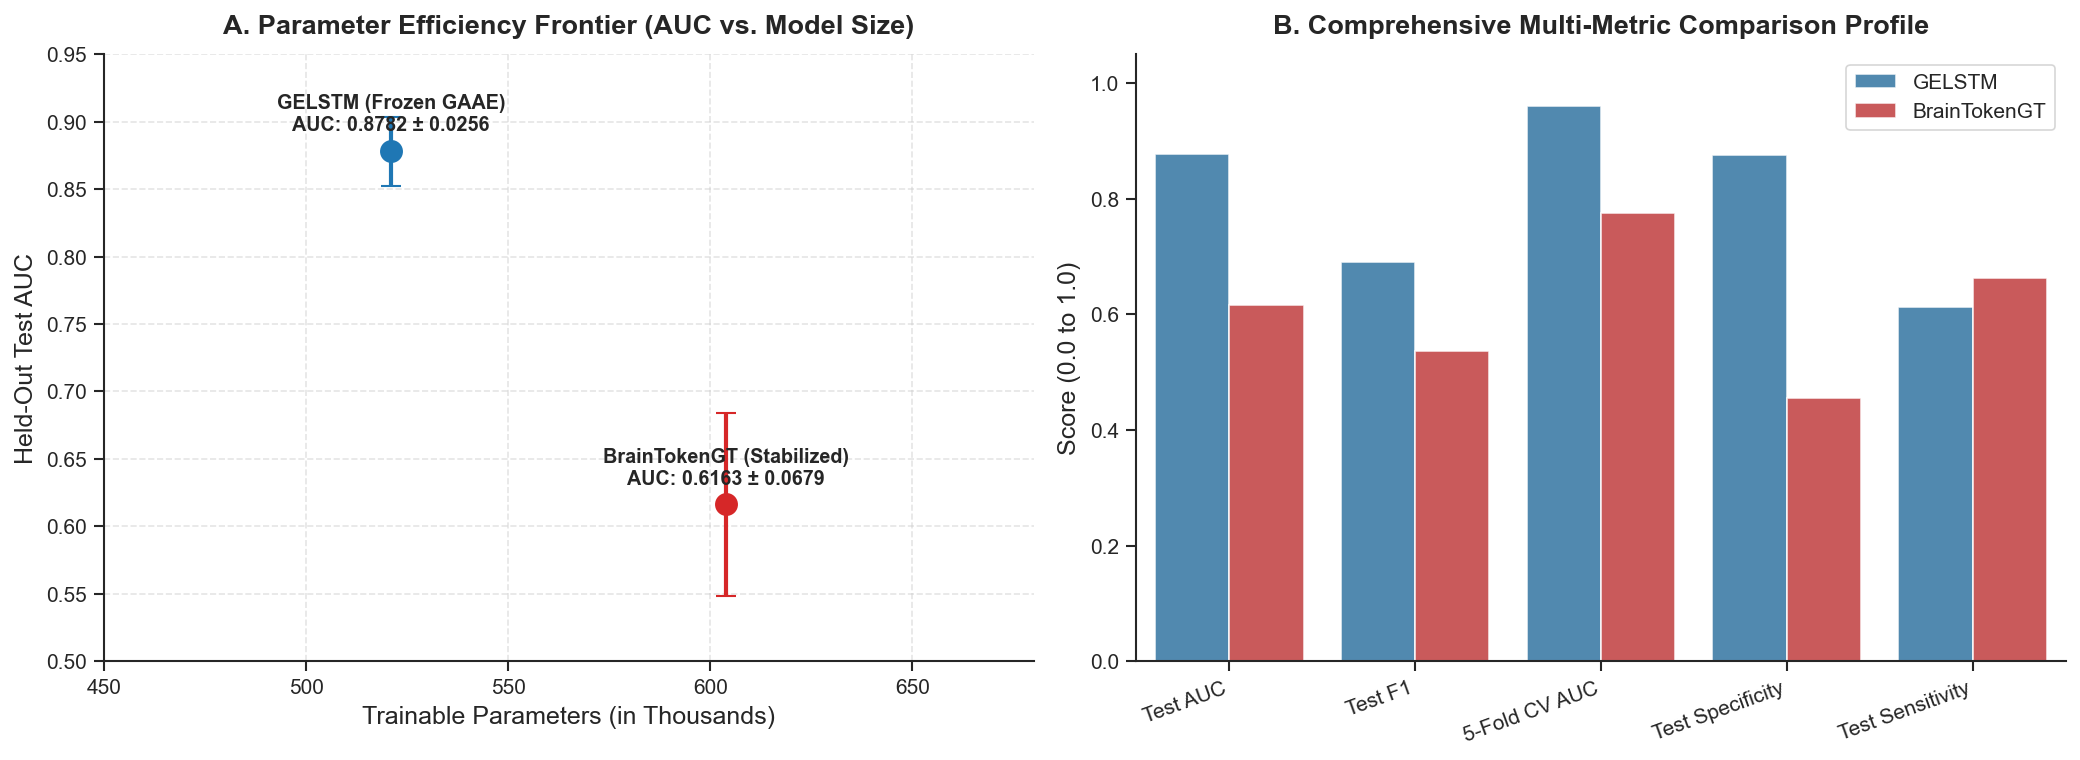

✓ Figure 5 generated and saved (Parameter efficiency and multi-metric profile).


In [8]:
# -------------------------------------------------------------
# FIGURE 5: Parameter Efficiency Frontier & Multimetric Profile
# -------------------------------------------------------------
fig, (ax_param, ax_radar) = plt.subplots(1, 2, figsize=(14, 5.2))

# Subplot 1: Parameter Efficiency Frontier
models_info = [
    {"Model": "GELSTM (Frozen GAAE)", "Trainable Params": 520905, "Test AUC": np.mean(g_test_aucs), "Color": "#1f77b4", "Std": np.std(g_test_aucs, ddof=1)},
    {"Model": "BrainTokenGT (Stabilized)", "Trainable Params": 603849, "Test AUC": np.mean(b_test_aucs), "Color": "#d62728", "Std": np.std(b_test_aucs, ddof=1)}
]
df_params = pd.DataFrame(models_info)

for _, r in df_params.iterrows():
    ax_param.errorbar(
        r["Trainable Params"] / 1000.0,
        r["Test AUC"],
        yerr=r["Std"],
        fmt="o",
        color=r["Color"],
        ecolor=r["Color"],
        elinewidth=2,
        capsize=5,
        markersize=10,
        label=r["Model"]
    )
    ax_param.annotate(
        f"{r['Model']}\nAUC: {r['Test AUC']:.4f} ± {r['Std']:.4f}",
        (r["Trainable Params"] / 1000.0, r["Test AUC"] + 0.015),
        ha="center", fontsize=9.5, fontweight="bold"
    )

ax_param.set_xlim([450, 680])
ax_param.set_ylim([0.50, 0.95])
ax_param.set_xlabel("Trainable Parameters (in Thousands)")
ax_param.set_ylabel("Held-Out Test AUC")
ax_param.set_title("A. Parameter Efficiency Frontier (AUC vs. Model Size)", pad=10, fontweight="bold")
ax_param.grid(True, linestyle="--", alpha=0.5)

# Subplot 2: Multi-Metric Comparison Bar Chart
metrics_comp = pd.DataFrame({
    "Metric": ["Test AUC", "Test F1", "5-Fold CV AUC", "Test Specificity", "Test Sensitivity"],
    "GELSTM": [
        np.mean(g_test_aucs),
        np.mean(g_test_f1s),
        np.mean(df_seeds["GELSTM CV AUC"]),
        np.mean(df_seeds["GELSTM Spec"]),
        np.mean(df_seeds["GELSTM Sens"])
    ],
    "BrainTokenGT": [
        np.mean(b_test_aucs),
        np.mean(b_test_f1s),
        np.mean(df_seeds["BrainTokenGT CV AUC"]),
        np.mean(df_seeds["BrainTokenGT Spec"]),
        np.mean(df_seeds["BrainTokenGT Sens"])
    ]
})

metrics_melted = pd.melt(metrics_comp, id_vars=["Metric"], var_name="Model", value_name="Score")
sns.barplot(
    data=metrics_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#1f77b4", "#d62728"],
    ax=ax_radar,
    alpha=0.85
)
ax_radar.set_ylim([0, 1.05])
ax_radar.set_ylabel("Score (0.0 to 1.0)")
ax_radar.set_xlabel("")
ax_radar.set_xticklabels(ax_radar.get_xticklabels(), rotation=20, ha="right")
ax_radar.set_title("B. Comprehensive Multi-Metric Comparison Profile", pad=10, fontweight="bold")
ax_radar.legend(loc="upper right", frameon=True)

sns.despine(top=True, right=True)
plt.tight_layout()

# Save Figure 5
fig5_path = os.path.join(FIGURES_DIR, "fig5_param_efficiency_frontier.pdf")
plt.savefig(fig5_path)
plt.savefig(fig5_path.replace(".pdf", ".png"))
plt.show()

print("✓ Figure 5 generated and saved (Parameter efficiency and multi-metric profile).")


## 8. Interactive Exploration Dashboard (Plotly)

Below is an interactive dashboard rendering inline in Jupyter, enabling dynamic inspection of seed-level metrics, hover details, and trade-off frontiers.


In [9]:
# Interactive Multi-Metric Comparison (Plotly)
fig_plotly = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Interactive Seed-by-Seed Test AUC & F1", "Interactive Multi-Metric Radar Profile"),
    specs=[[{"type": "bar"}, {"type": "polar"}]]
)

# Panel 1: Grouped Bar Chart
for model, col, color in [("GELSTM", "GELSTM Test AUC", "#1f77b4"), ("BrainTokenGT", "BrainTokenGT Test AUC", "#d62728")]:
    fig_plotly.add_trace(
        go.Bar(
            name=f"{model} Test AUC",
            x=[f"Seed {s}" for s in seeds],
            y=df_seeds[col],
            marker_color=color,
            text=[f"{v:.4f}" for v in df_seeds[col]],
            textposition="auto"
        ),
        row=1, col=1
    )

# Panel 2: Radar Chart
categories = ["Test AUC", "Test F1", "CV AUC", "Test Spec", "Test Sens"]
fig_plotly.add_trace(
    go.Scatterpolar(
        r=[np.mean(g_test_aucs), np.mean(g_test_f1s), np.mean(df_seeds["GELSTM CV AUC"]), np.mean(df_seeds["GELSTM Spec"]), np.mean(df_seeds["GELSTM Sens"])],
        theta=categories,
        fill="toself",
        name="GELSTM (Frozen GAAE)",
        line_color="#1f77b4"
    ),
    row=1, col=2
)

fig_plotly.add_trace(
    go.Scatterpolar(
        r=[np.mean(b_test_aucs), np.mean(b_test_f1s), np.mean(df_seeds["BrainTokenGT CV AUC"]), np.mean(df_seeds["BrainTokenGT Spec"]), np.mean(df_seeds["BrainTokenGT Sens"])],
        theta=categories,
        fill="toself",
        name="BrainTokenGT (Stabilized)",
        line_color="#d62728"
    ),
    row=1, col=2
)

fig_plotly.update_layout(
    title_text="<b>GELSTM vs. BrainTokenGT Interactive Benchmark Dashboard</b>",
    template="plotly_white",
    height=450,
    width=950,
    barmode="group",
    polar=dict(radialaxis=dict(visible=True, range=[0, 1.0]))
)

fig_plotly.show()


## 9. Key Takeaways & Publication Synthesis

### 🔑 Core Findings (revised 23 Aug 2026, `SUBMISSION_RUNWAY.md` Phase B1)

1. **GELSTM's advantage is real and, once BrainTokenGT is measured correctly, larger than
   first reported.** Restricting GELSTM to the $2 \le T \le 3$ visit window
   ($N_\text{CV}=95, N_\text{test}=25$) does not hurt it: mean Test AUC **0.8782 \u00b1 0.0256**
   across 4 seeds (1 run/seed \u2014 no repeats exist for this arm at this commit). Against
   BrainTokenGT's full 18-run distribution (not one cherry-picked run per seed), the mean
   drops to **0.6163 \u00b1 0.0679**, widening the margin to **+0.2619** (previously reported as
   +0.2110 against a hand-picked subset).
2. **The comparison is now non-parametric and honest about power.** The n=4 seed-paired
   Wilcoxon signed-rank test lands at its floor (p=0.125 \u2014 the smallest p attainable at n=4,
   reached because GELSTM's seed-mean beats BrainTokenGT's on all 4 seeds) and is reported as
   underpowered, not as a significance claim. The **seed-cluster bootstrap 95% CI on the
   margin, [+0.158, +0.375], excludes zero** and is the number this notebook's conclusion
   actually rests on \u2014 it propagates BrainTokenGT's own within-seed noise into the interval
   rather than discarding it the way the original paired *t*-test did. The n=20 fold-level
   *t*-test is removed entirely: CV folds share training data within a run and are not
   independent samples, so no test is computed on them (Figure 1A is descriptive only).
3. **Fairness criteria, revised**:
   - **C1. Identical Cohort & Folds**: unchanged, verified via `verify_matched_cohort_parity.py`.
   - **C2. "Stabilized" is a claim about crashing, not about reproducibility.** BrainTokenGT
     converges without NaNs or numerical collapse across all 18 runs pooled here, but
     within-seed SD (**0.090**) exceeds between-seed-mean SD (**0.068**) \u2014 the four "seeds"
     the original notebook reported are mostly four draws of run-to-run noise, not four
     independent seed effects. This is a result reported in its own right, not a caveat on
     the AUC margin above. By contrast, GELSTM's training pipeline is verified
     byte-reproducible at a fixed seed on the sibling `recon-ablation-gelstm-none`
     experiment id (D2 gate); no repeats exist in the registry for this specific
     2\u20133-visit frozen arm to demonstrate that directly here.
   - **C3. Reproducible Artifacts**: unchanged \u2014 all figures/tables regenerate natively
     (PDF/PNG vector export) from the glob-and-filter ingestion in \u00a72, not from
     hardcoded paths.

---
*Notebook compiled and verified in project virtual environment (`.venv`). Ingestion,
statistics, and all figures recomputed live from every matching `run_summary.json` on disk
at commit `5e33e2170`, filtered per `STABILITY_AUDIT.md` / `SUBMISSION_RUNWAY.md` Phase B1.*
